<a href="https://colab.research.google.com/github/guzik1234/DataScienceCwiczenia/blob/main/seaborn/praktyka47.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://ml-repository-krakers.s3-eu-west-1.amazonaws.com/kaggle+/churn_modelling/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.TotalCharges.value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [5]:
df.TotalCharges.sort_values()

,TotalCharges
936,
3826,
4380,
753,
5218,
...,...
6646,997.75
5598,998.1
3686,999.45
3353,999.8


In [10]:
TotalChargesMedian =  df[df.TotalCharges != ' ']['TotalCharges'].astype('float32').median()

In [15]:
df['TotalCharges'][df['TotalCharges'] == ' '] = TotalChargesMedian

df['TotalCharges'] = df['TotalCharges'].astype('float32')

/tmp/ipykernel_536/3105871622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalCharges'][df['TotalCharges'] == ' '] = TotalChargesMedian


In [13]:
df.TotalCharges.value_counts()

,count
TotalCharges,
1397.475098,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
if not df.isnull().sum().sum():
  print("nie ma brakow")

nie ma brakow


In [23]:
numerical = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in categorical:
  df[col] = pd.Categorical(df[col])
for col in numerical:
  df[col] = df[col].astype('float32')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   float32 
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [24]:
df = df.drop(columns=['customerID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   category
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   category
 3   Dependents        7043 non-null   category
 4   tenure            7043 non-null   float32 
 5   PhoneService      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   InternetService   7043 non-null   category
 8   OnlineSecurity    7043 non-null   category
 9   OnlineBackup      7043 non-null   category
 10  DeviceProtection  7043 non-null   category
 11  TechSupport       7043 non-null   category
 12  StreamingTV       7043 non-null   category
 13  StreamingMovies   7043 non-null   category
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [25]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371147,64.761696,2281.916992
std,24.559708,30.089973,2265.270752
min,0.000000,18.250000,18.799999
25%,9.000000,35.500000,402.225006
50%,29.000000,70.349998,1397.475098
75%,55.000000,89.849998,3786.599976
max,72.000000,118.750000,8684.799805


In [26]:
df.describe(include=['category'])

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,3,3,3,3,3,3,3,3
top,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No
freq,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785


Churn
No     5174
Yes    1869
Name: count, dtype: int64


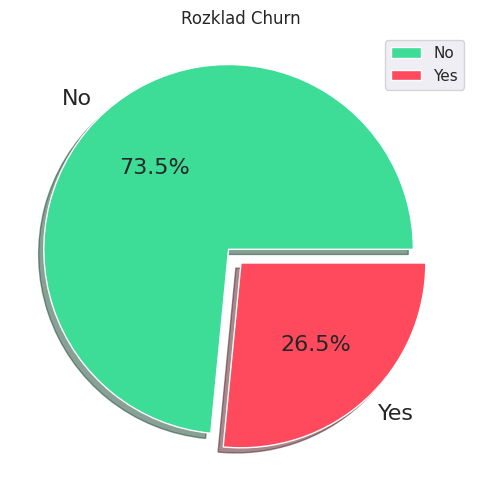

In [39]:
from enum import auto
plt.figure(figsize=(8,6))
sns.set()
df.Churn.value_counts().plot(kind='pie',
                             fontsize=16,
                             colors=['#3DDC97', '#FF495C'],
                             explode=[0.1,0],
                             shadow=True,
                             autopct='%1.1f%%',
                             )
plt.legend()
plt.ylabel('')
plt.title('Rozklad Churn')
print(df.Churn.value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


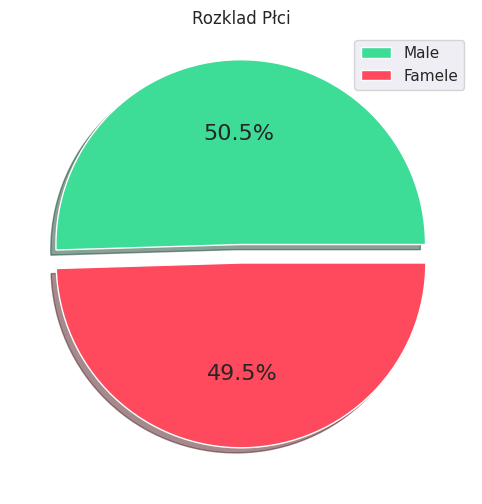

In [44]:
from enum import auto
plt.figure(figsize=(8,6))
sns.set()
df.gender.value_counts().plot(kind='pie',
                             fontsize=16,
                             labels= ['', ''],
                             colors=['#3DDC97', '#FF495C'],
                             explode=[0.1,0],
                             shadow=True,
                             autopct='%1.1f%%',
                             )
plt.legend(['Male', 'Famele'])
plt.ylabel('')
plt.title('Rozklad Płci')
print(df.Churn.value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


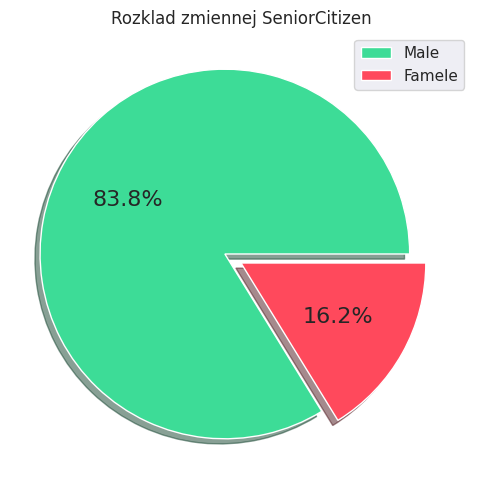

In [45]:
from enum import auto
plt.figure(figsize=(8,6))
df.SeniorCitizen.value_counts().plot(kind='pie',
                             fontsize=16,
                             labels= ['', ''],
                             colors=['#3DDC97', '#FF495C'],
                             explode=[0.1,0],
                             shadow=True,
                             autopct='%1.1f%%',
                             )
plt.legend(['Male', 'Famele'])
plt.ylabel('')
plt.title('Rozklad zmiennej SeniorCitizen')
print(df.Churn.value_counts())

/tmp/ipykernel_536/1690333996.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  _ = sns.distplot(df.MonthlyCharges, bins=30)


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

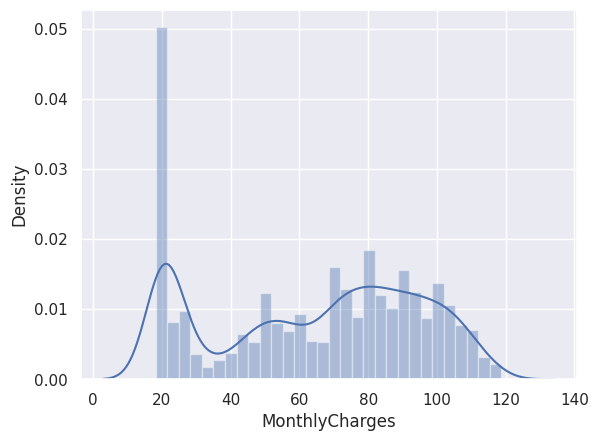

In [48]:
sns.distplot(df.MonthlyCharges, bins=30)


/tmp/ipykernel_536/2591601497.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.tenure, bins=30)


<Axes: xlabel='tenure', ylabel='Density'>

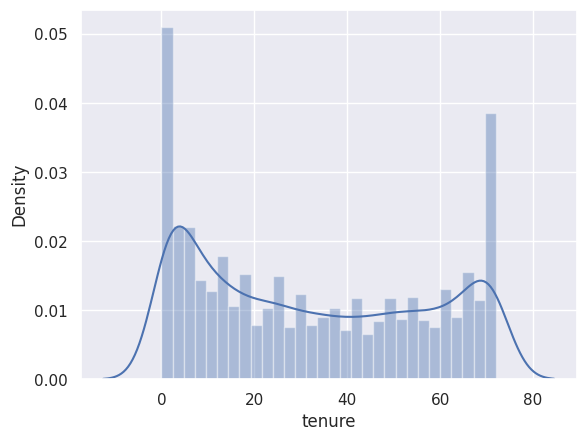

In [49]:
sns.distplot(df.tenure, bins=30)


/tmp/ipykernel_536/2549037487.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.MonthlyCharges, bins=30, ax=ax[0])
/tmp/ipykernel_536/2549037487.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.tenure, bins=30, ax=ax[1])


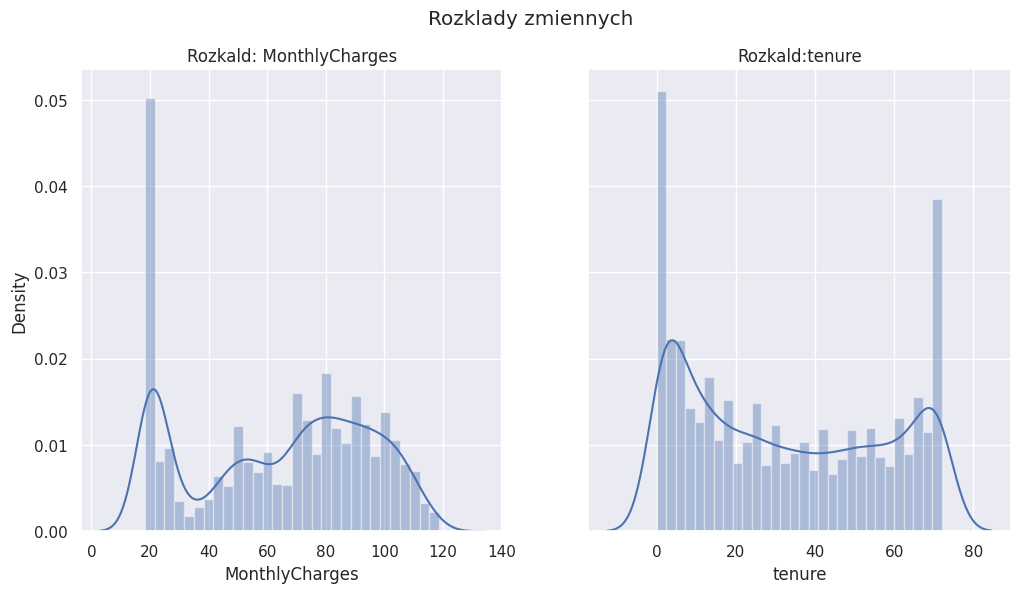

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(12, 6))
sns.distplot(df.MonthlyCharges, bins=30, ax=ax[0])
sns.distplot(df.tenure, bins=30, ax=ax[1])

fig.suptitle('Rozklady zmiennych')
ax[0].title.set_text('Rozkald: MonthlyCharges')
ax[1].title.set_text('Rozkald:tenure')

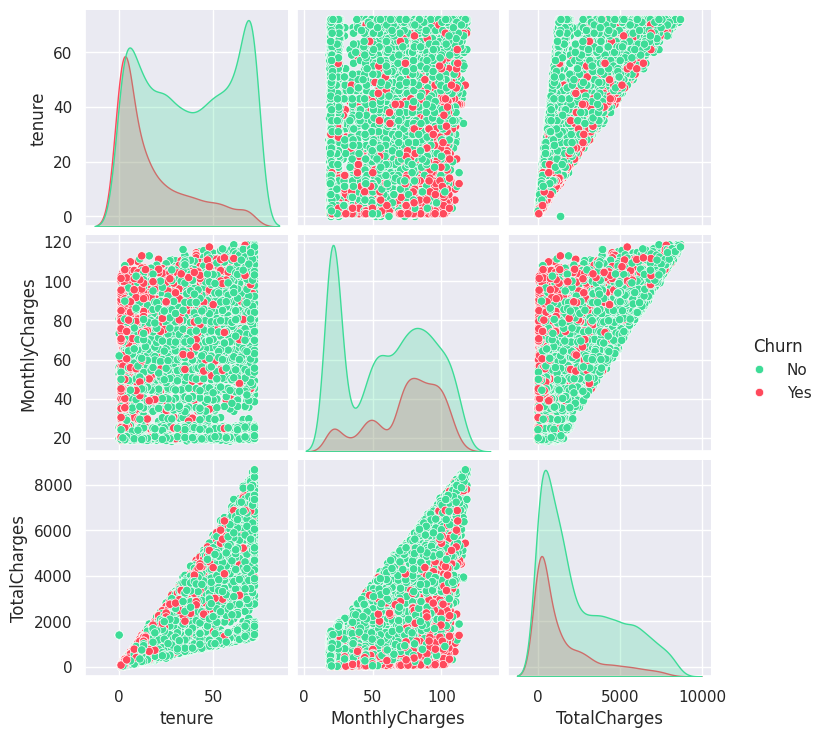

In [55]:
sns.pairplot(data=df, vars=['tenure', 'MonthlyCharges', 'TotalCharges'], hue='Churn', palette=['#3DDC97', '#FF495C'])

/tmp/ipykernel_536/1654314008.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x='Churn', y='MonthlyCharges', kind='violin', palette=['#3DDC97', '#FF495C'])


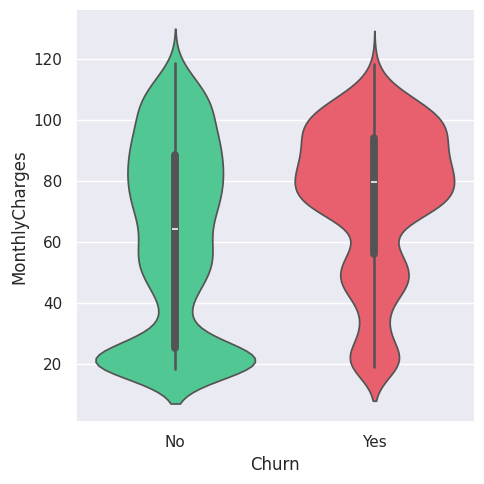

In [57]:
sns.catplot(data=df, x='Churn', y='MonthlyCharges', kind='violin', palette=['#3DDC97', '#FF495C'])

ValueError: could not convert string to float: 'Female'